Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already extracted. Skipping.
✅ Found 6 classes: ['YOU_LIVE_WHAT_CITY' 'NICE_MEET_YOO' 'YOU_FROM' 'DEAF_YOU'
 'YOUR_TEACHER_WHAT_NAME' 'YOU_NAME_WHAT']
Loading data into memory...
📊 Training samples: 153
📊 Test samples: 27


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting Training (Optimized for Small Dataset)...
⏱️ Will train patiently with adaptive learning rate

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 347ms/step - categorical_accuracy: 0.1786 - loss: 6.3991 - val_categorical_accuracy: 0.1250 - val_loss: 2.1382 - learning_rate: 0.0010
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - categorical_accuracy: 0.1395 - loss: 2.0147 - val_categorical_accuracy: 0.2500 - val_loss: 1.7349 - learning_rate: 0.0010
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - categorical_accuracy: 0.1794 - loss: 1.8142 - val_categorical_accuracy: 0.0625 - val_loss: 1.8177 - learning_rate: 0.0010
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.1474 - loss: 1.8412 - val_categorical_accuracy: 0.0625 - val_loss: 1.8999 - learning_rate: 0.0010
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - categorical_accuracy: 0.1647 - loss: 1.8409 - val_categorical_accuracy: 0.4375 - val_loss: 1.7299 - learning_rate: 0.0010
Epoch 6/200
18

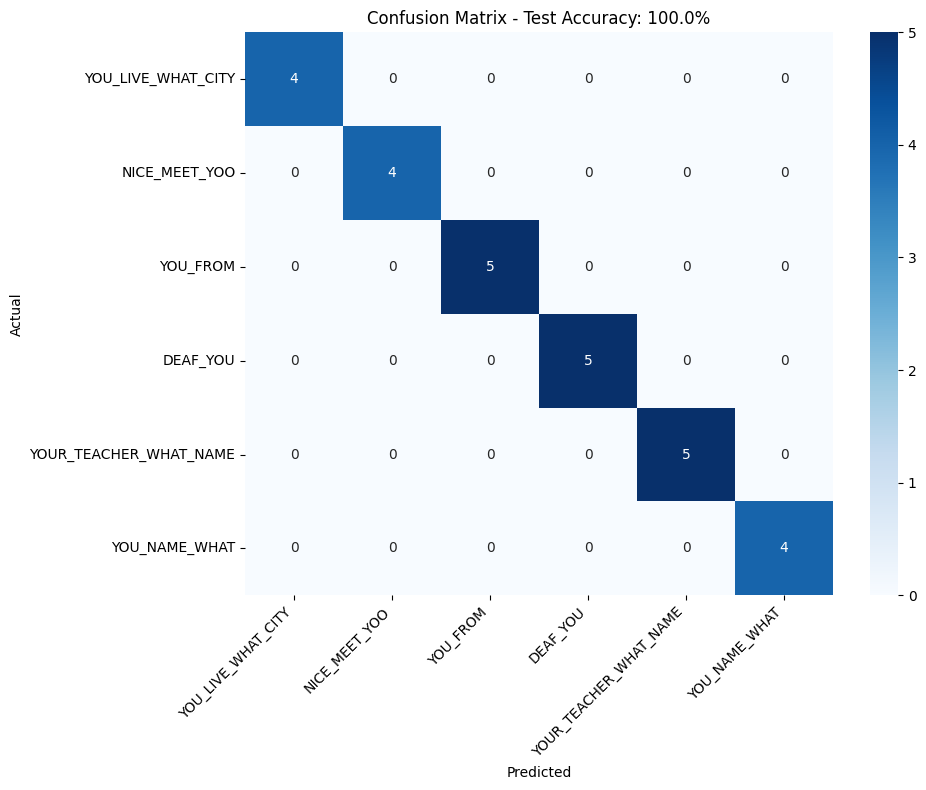

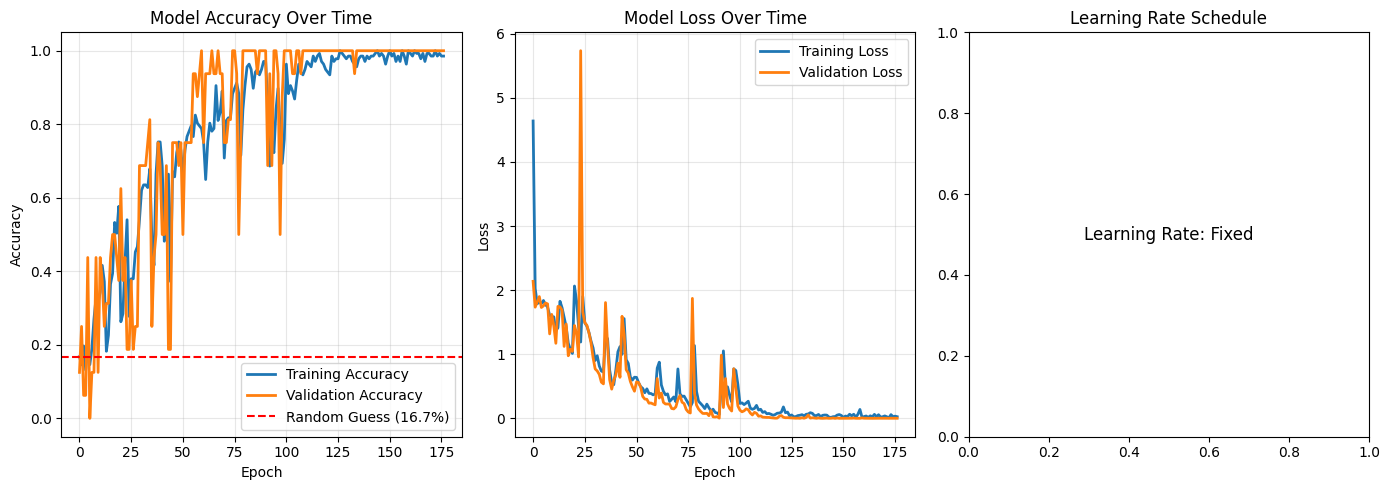


💡 Diagnosis Guide:
   - Curves close together + high accuracy → Good generalization ✅
   - Training high, validation low → Overfitting (need more data) ⚠️
   - Both low + stuck near random guess → Underfitting (need more capacity/epochs) ⚠️

✅ Model saved to: /content/drive/MyDrive/sign_language_model_v2.h5
✅ Label mapping saved to: /content/drive/MyDrive/label_map.npy


In [14]:
# --- BLOCK 1: MOUNT DRIVE & SETUP (RAR SUPPORT FIXED) ---
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. EXACT PATH based on your error log
# You put it inside a folder called "Sign"
drive_file_path = '/content/drive/MyDrive/Sign/MP_Data.rar'

# 3. Copy and Extract
if not os.path.exists('MP_Data'):
    if os.path.exists(drive_file_path):
        print(f"Found file at {drive_file_path}. Copying...")

        # Copy file to Colab machine
        filename = os.path.basename(drive_file_path)
        !cp "$drive_file_path" .

        # Check if it is RAR or ZIP
        if filename.endswith('.rar'):
            print("Detected .rar file. Installing unrar...")
            !apt-get install unrar > /dev/null  # Install unrar tool
            print("Extracting (this might take a minute)...")
            !unrar x "$filename" > /dev/null    # Extract
        else:
            print("Detected .zip file. Extracting...")
            !unzip -q "$filename"

        print("Data ready!")
    else:
        print(f"ERROR: Could not find file at: {drive_file_path}")
        print("Check if the folder 'Sign' exists in your Drive and 'MP_Data.rar' is inside it.")
        raise FileNotFoundError("File not found in Drive.")
else:
    print("Data already extracted. Skipping.")

# --- BLOCK 2: LOAD DATA ---
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

DATA_PATH = os.path.join('MP_Data')

# Automatically detect your words
try:
    actions = np.array([folder for folder in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, folder))])
    print(f"Found {len(actions)} classes: {actions}")
except FileNotFoundError:
    print("ERROR: MP_Data folder is empty or missing.")
    raise

label_map = {label:num for num, label in enumerate(actions)}

sequences, labels = [], []

print("Loading data into memory...")

for action in actions:
    for sequence in range(30):
        window = []
        try:
            for frame_num in range(30):
                res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
                window.append(res)
            sequences.append(window)
            labels.append(label_map[action])
        except Exception as e:
            print(f"Warning: Missing data in {action}/{sequence}")

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# OPTIMIZED: Smaller test split for small dataset (144 samples)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=labels)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# --- BLOCK 3: BUILD & TRAIN (OPTIMIZED FOR SMALL DATASET) ---
model = Sequential()

# Layer 1: LSTM (no dropout - small dataset)
model.add(LSTM(128, return_sequences=True, activation='relu', input_shape=(30,1662)))

# Layer 2: LSTM with light dropout
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(Dropout(0.2))  # REDUCED: Lighter dropout for small dataset

# Layer 3: LSTM with light dropout
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dropout(0.2))  # REDUCED: Lighter dropout

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))  # Moderate dropout here only
model.add(Dense(actions.shape[0], activation='softmax'))

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# IMPROVED CALLBACKS
# 1. Early Stopping - more patient for small datasets
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,  # INCREASED: More patience to let model learn
    restore_best_weights=True,
    verbose=1
)

# 2. Learning Rate Reduction - helps convergence
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

print("Starting Training (Optimized for Small Dataset)...")
print("⏱Will train patiently with adaptive learning rate\n")

# FIXED: Smaller validation split + more epochs
history = model.fit(
    X_train, y_train,
    epochs=200,  # More epochs allowed (EarlyStopping will stop when needed)
    validation_split=0.10,  # REDUCED: Only 10% validation (was 15%)
    callbacks=[early_stop, reduce_lr],
    batch_size=8,  # ADDED: Smaller batches for better learning
    verbose=1
)

# --- BLOCK 4: EVALUATE MODEL ---
print("\n" + "="*50)
print("EVALUATING MODEL ON TEST SET")
print("="*50)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Check for overfitting/underfitting
final_train_acc = history.history['categorical_accuracy'][-1]
final_val_acc = history.history['val_categorical_accuracy'][-1]

print(f"\n Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f" Final Validation Accuracy: {final_val_acc*100:.2f}%")

if test_accuracy < 0.50:
    print("\n LOW ACCURACY WARNING:")
    print("   - Model is underfitting (not learning enough)")
    print("   - Try: More training data, simpler model, or longer training")
elif abs(final_train_acc - test_accuracy) > 0.20:
    print("\n OVERFITTING WARNING:")
    print("   - Training accuracy much higher than test accuracy")
    print("   - Try: More dropout, more training data, or data augmentation")
else:
    print("\n Model looks healthy! Good balance between training and test performance.")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Show some predictions
print("\n Sample Predictions vs Actual:")
for i in range(min(15, len(y_test_classes))):
    pred_label = actions[y_pred_classes[i]]
    true_label = actions[y_test_classes[i]]
    confidence = y_pred[i][y_pred_classes[i]] * 100
    status = "" if pred_label == true_label else "Error"
    print(f"{status} Predicted: {pred_label:25s} ({confidence:5.1f}%) | Actual: {true_label}")

# --- BLOCK 5: CONFUSION MATRIX ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*50)
print(" DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_classes, y_pred_classes, target_names=actions, zero_division=0))

# Plot confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=actions, yticklabels=actions)
plt.title(f'Confusion Matrix - Test Accuracy: {test_accuracy*100:.1f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- BLOCK 6: TRAINING HISTORY VISUALIZATION ---
plt.figure(figsize=(14, 5))

# Plot accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['categorical_accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy', linewidth=2)
plt.axhline(y=1.0/len(actions), color='r', linestyle='--', label=f'Random Guess ({1.0/len(actions)*100:.1f}%)')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot learning rate (if changed)
plt.subplot(1, 3, 3)
if 'lr' in history.history:
    plt.plot(history.history['lr'], linewidth=2, color='green')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Learning Rate: Fixed', ha='center', va='center', fontsize=12)
    plt.title('Learning Rate Schedule')

plt.tight_layout()
plt.show()

print("\n Diagnosis Guide:")
print("   - Curves close together + high accuracy → Good generalization ")
print("   - Training high, validation low → Overfitting (need more data) ")
print("   - Both low + stuck near random guess → Underfitting (need more capacity/epochs) ")

# --- BLOCK 7: SAVE TO DRIVE ---
if test_accuracy > 0.60:  # Only save if reasonably good
    model_save_path = '/content/drive/MyDrive/sign_language_model_v2.h5'
    model.save(model_save_path)
    print(f"\n Model saved to: {model_save_path}")

    # Save the label mapping
    label_save_path = '/content/drive/MyDrive/label_map.npy'
    np.save(label_save_path, actions)
    print(f" Label mapping saved to: {label_save_path}")
else:
    print(f"\n Model accuracy ({test_accuracy*100:.1f}%) too low to save.")
    print("   Consider: collecting more training videos or adjusting model architecture.")
